In [1]:
import os
from pathlib import Path

import contextily as cx
import geopandas as gpd
import libpysal
import matplotlib.pyplot as plt
import numpy as np
import rasterio as rio
import rasterio.features as rio_features
import shapely
from esda.getisord import G_Local

In [2]:
data_path = Path(os.environ["DATA_PATH"])

In [3]:
bounds = gpd.read_file(data_path / "lim_aumxl24").to_crs("EPSG:6372")["geometry"].item()

In [4]:
with rio.open(data_path / "LST" / "02 MXL_LSTdia_20210825.tif") as ds:
    data = ds.read(1)
    data[data == ds.nodata] = 0
    data[np.isnan(data)] = 0

    transform = ds.transform

    mask = data != 0
    df_geom = [
        (shapely.geometry.shape(j), v)
        for j, v in rio_features.shapes(
            data,
            connectivity=8,
            transform=transform,
            mask=mask,
        )
    ]
    df_geom = gpd.GeoDataFrame(
        df_geom,
        crs=ds.crs,
        columns=["geometry", "value"],
        geometry="geometry",
    )

df_geom = df_geom.to_crs("EPSG:6372").reset_index(names="index")
df_geom = df_geom[df_geom.intersects(bounds)]

# Getis-Ord

In [5]:
w = libpysal.weights.Queen.from_dataframe(df_geom)
g = G_Local(df_geom["value"], w, transform="B")

/var/folders/yq/0mz24vy927s9m5vjh6gqb6040000gn/T/ipykernel_19293/716572705.py:1: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  w = libpysal.weights.Queen.from_dataframe(df_geom)


In [6]:
sig = g.p_sim < 0.05
hh = df_geom.loc[(g.Zs > 0) & sig]

hh_cat = hh.assign(
    component=libpysal.weights.Queen.from_dataframe(hh).component_labels,
).dissolve(
    by="component",
    aggfunc={"value": "median", "index": list},
)

/var/folders/yq/0mz24vy927s9m5vjh6gqb6040000gn/T/ipykernel_19293/3222485182.py:5: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  component=libpysal.weights.Queen.from_dataframe(hh).component_labels,
/Users/rodolfofigueroa/Documents/mexicali-zone/.venv/lib/python3.11/site-packages/libpysal/weights/contiguity.py:347: UserWarning: The weights matrix is not fully connected: 
 There are 304 disconnected components.
 There are 38 islands with ids: 0, 242, 1688, 7906, 11160, 14800, 19286, 20062, 21216, 21885, 23718, 27405, 33775, 34591, 34598, 35576, 35925, 36630, 37061, 41996, 42879, 44832, 46415, 46796, 55385, 70371, 74467, 74475, 79142, 81405, 83780, 84867, 85492, 86891, 87432, 87716, 88769, 89250.
  W.__init__(self, neighbors, ids=ids, **kw)


In [17]:
hh_cat["value"].median()

59.857391357421875

<Axes: >

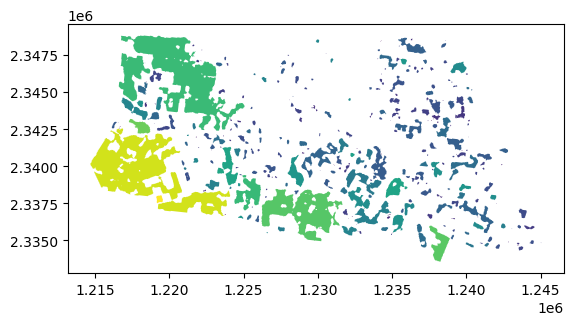

In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))
hh_cat.plot(column="value", vmin=np.)

In [7]:
area_thresh = 0.5 * 1e6
components = hh_cat[hh_cat.area > area_thresh]
component_idx = set(components["index"].sum())

hh_filtered = hh.query("index.isin(@component_idx)").to_crs("EPSG:4326")

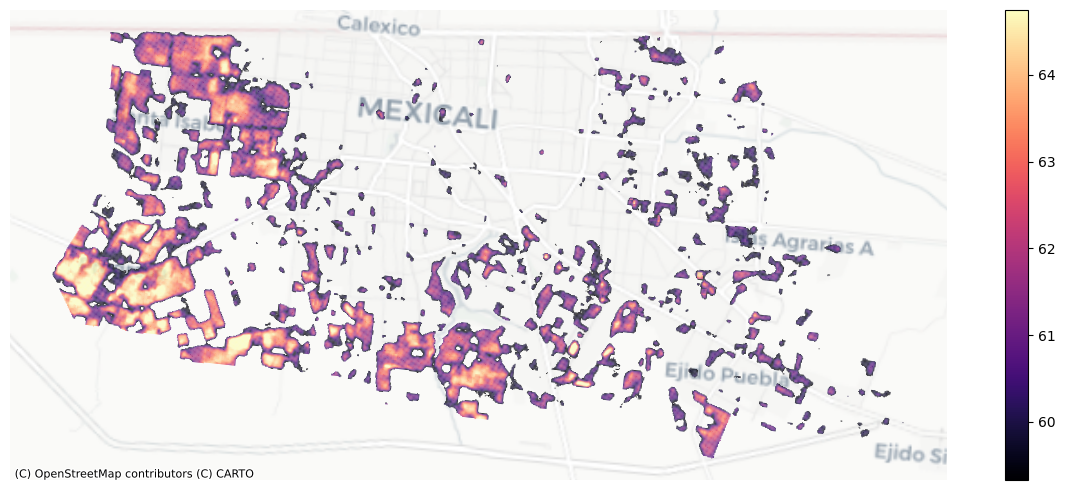

In [8]:
temp = hh

vmin = temp["value"].quantile(0.02)
vmax = temp["value"].quantile(0.98)

fig, ax = plt.subplots(figsize=(12, 5))
temp.plot(
    column="value",
    ax=ax,
    lw=0,
    ec="none",
    legend=True,
    vmin=vmin,
    vmax=vmax,
    cmap="magma",
)
cx.add_basemap(ax, source=cx.providers.CartoDB.Positron, crs=temp.crs)
ax.axis("off")
fig.tight_layout()

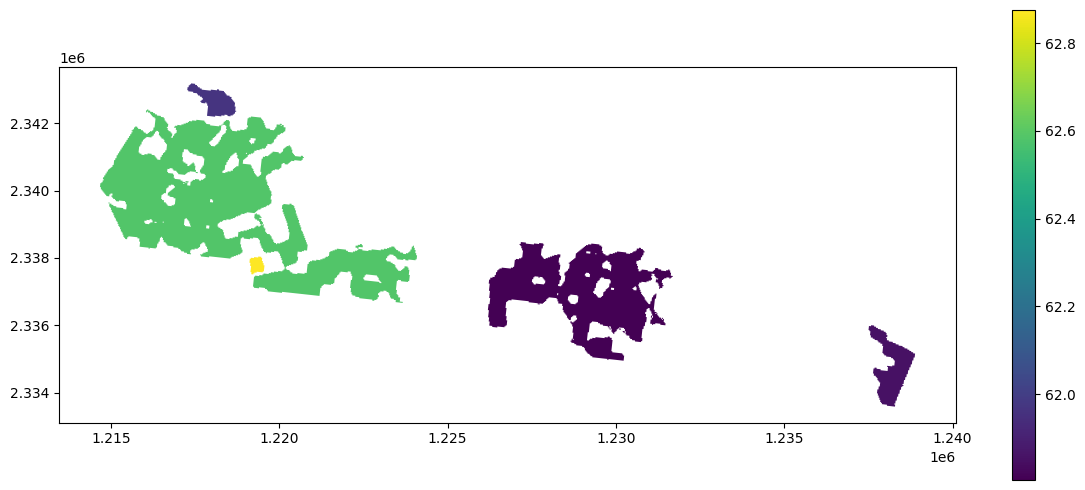

In [52]:
fig, ax = plt.subplots(figsize=(12, 5))
hh_cat.sort_values("value", ascending=False).head(5).plot(
    column="value",
    legend=True,
    ax=ax,
)
fig.tight_layout()

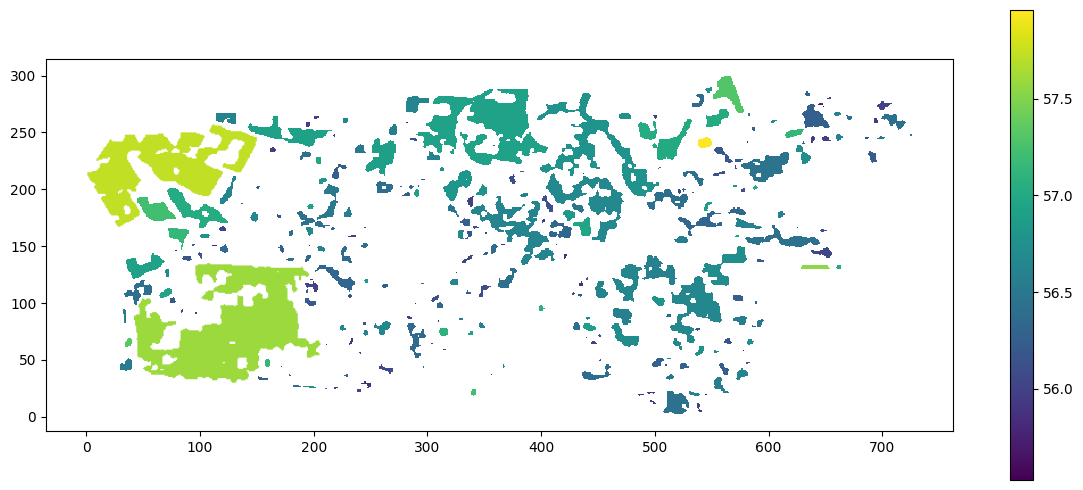

In [ ]:
fig, ax = plt.subplots(figsize=(12, 5))
hh.plot(column="value", legend=True, ax=ax, cmap="viridis")
fig.tight_layout()

In [ ]:
w = libpysal.weights.Queen.from_dataframe(gdf)

/var/folders/yq/0mz24vy927s9m5vjh6gqb6040000gn/T/ipykernel_18152/2898234147.py:1: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  w = libpysal.weights.Queen.from_dataframe(gdf)
